<a href="https://colab.research.google.com/github/aliaa-anx/review-sentiment-analysis-/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import zipfile
import os


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Path to your uploaded zip file
zip_path = '/content/drive/MyDrive/IMDB Dataset.csv.zip'

# Path where you want to extract the files
extract_path = '/content/extracted_dataset'

# Uncompressing the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete. Files in folder:", os.listdir(extract_path))

Extraction complete. Files in folder: ['IMDB Dataset.csv']


In [17]:
# Define the path to the extracted file
# (Check the print output from the previous step to confirm the exact filename)
file_name = extract_path + '/IMDB Dataset.csv'

import pandas as pd

# Standard CSV loading
df = pd.read_csv(file_name)

# If it's actually a TSV file but named .csv:
# df = pd.read_csv(file_name, sep='\t')

print(f"Successfully loaded {len(df)} reviews.")
print(df.head())


Successfully loaded 50000 reviews.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('stopwords')      # download these while you're at it
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [19]:
from transformers import pipeline

ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

def apply_ner(text):
    results = ner(text[:512])  # BERT has 512 token limit
    new_text = text
    # Replace in reverse to avoid index shifting
    for entity in sorted(results, key=lambda x: x['start'], reverse=True):
        if entity['entity_group'] == 'PER':
            new_text = new_text[:entity['start']] + '[PERSON]' + new_text[entity['end']:]
        elif entity['entity_group'] in ['MISC', 'ORG']:
            new_text = new_text[:entity['start']] + '[MOVIE_NAME]' + new_text[entity['end']:]
    return new_text

df['processed_text'] = df['review'].apply(apply_ner)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [20]:
# Check a few random rows
for i in range(5):
    print(f"--- Review {i} ---")
    print(f"ORIGINAL: {df['review'].iloc[i][:500]}...") # First 150 chars
    print(f"PROCESSED: {df['processed_text'].iloc[i][:500]}...")
    print("\n")

--- Review 0 ---
ORIGINAL: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ...
PROCESSED: One of the other reviewers has mentioned that after watching just 1 [MOVIE_NAME] episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the

In [23]:
from google.colab import drive
drive.mount('/content/drive')

# Save the dataframe with original + processed text
df[['review', 'processed_text', 'sentiment']].to_csv(
    '/content/drive/MyDrive/IMDB_processed_NER.csv', index=False
)

print(' Saved IMDB_processed_NER.csv to Google Drive!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Saved IMDB_processed_NER.csv to Google Drive!


In [27]:
import pandas as pd

# From Drive
df = pd.read_csv('/content/drive/MyDrive/IMDB_processed_NER.csv')

# OR if you're uploading from your PC
# from google.colab import files
# uploaded = files.upload()  # pick the file
# df = pd.read_csv('IMDB_processed_NER.csv')

print(f' Loaded {len(df):,} reviews — NER already applied, ready for preprocessing!')
df.head(3)

 Loaded 50,000 reviews — NER already applied, ready for preprocessing!


,review,processed_text,sentiment
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,positive


In [21]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    # 0. Remove NER placeholders FIRST before anything else
    text = re.sub(r'\[PERSON\]', ' ', text)
    text = re.sub(r'\[MOVIE_NAME\]', ' ', text)

    text = re.sub(r'\bin\b', ' ', text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove ALL HTML tags and entities
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Strip non-alphabetic characters
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]

    # 5. Remove stopwords + empty strings
    tokens = [t for t in tokens if t and t not in stop_words]

    return ' '.join(tokens)


print(' Rerunning preprocessing...')
df['cleaned_review'] = df['processed_text'].apply(preprocess_text)

print(' Rerunning lemmatization...')
df['cleaned_review'] = df['cleaned_review'].apply(
    lambda text: ' '.join(lemmatizer.lemmatize(word) for word in text.split())
)

print(' Done! Verifying...')

mask = df['cleaned_review'].str.split().apply(lambda x: 'in' in x)
print(f'Standalone "in" remaining : {mask.sum()}  (should be 0)')

 Rerunning preprocessing...
 Rerunning lemmatization...
 Done! Verifying...
Standalone "in" remaining : 40  (should be 0)


In [29]:
import random

sample_idx = random.randint(0, len(df))
original = df['review'].iloc[sample_idx]
processed_ner = df['processed_text'].iloc[sample_idx]

print('=' * 70)
print('STEP 0 — ORIGINAL RAW REVIEW')
print('=' * 70)
print(original[:500])

print('\n' + '=' * 70)
print('STEP 1 — AFTER NER (entities replaced with placeholders)')
print('=' * 70)
print(processed_ner[:500])

# Step 2: Remove placeholders
step2 = re.sub(r'\[PERSON\]', ' ', processed_ner)
step2 = re.sub(r'\[MOVIE_NAME\]', ' ', step2)
print('\n' + '=' * 70)
print('STEP 2 — AFTER PLACEHOLDER REMOVAL')
print('=' * 70)
print(step2[:500])

# Step 3: Lowercase
step3 = step2.lower()
print('\n' + '=' * 70)
print('STEP 3 — AFTER LOWERCASE')
print('=' * 70)
print(step3[:500])

# Step 4: Remove HTML
step4 = re.sub(r'<[^>]+>', ' ', step3)
step4 = re.sub(r'&[a-z]+;', ' ', step4)
print('\n' + '=' * 70)
print('STEP 4 — AFTER HTML REMOVAL')
print('=' * 70)
print(step4[:500])

# Step 5: Tokenization
step5 = word_tokenize(step4)
print('\n' + '=' * 70)
print('STEP 5 — AFTER TOKENIZATION')
print('=' * 70)
print(step5[:50])

# Step 6: Remove punctuation
step6 = [re.sub(r'[^a-z]', '', t) for t in step5]
step6 = [t for t in step6 if t]
print('\n' + '=' * 70)
print('STEP 6 — AFTER PUNCTUATION REMOVAL')
print('=' * 70)
print(step6[:50])

# Step 7: Remove stopwords
step7 = [t for t in step6 if t not in stop_words]
print('\n' + '=' * 70)
print('STEP 7 — AFTER STOPWORD REMOVAL')
print('=' * 70)
print(step7[:50])

# Step 8: Lemmatization
step8 = [lemmatizer.lemmatize(w) for w in step7]
print('\n' + '=' * 70)
print('STEP 8 — AFTER LEMMATIZATION')
print('=' * 70)
print(step8[:50])

print('\n' + '=' * 70)
print('FINAL — CLEANED REVIEW (joined)')
print('=' * 70)
print(' '.join(step8)[:500])

print('\n' + '=' * 70)
print(f' WORD COUNT REDUCTION')
print('=' * 70)
print(f'Original  : {len(original.split())} words')
print(f'Final     : {len(step8)} words')
print(f'Reduction : {100 - len(step8)/len(original.split())*100:.1f}%')

STEP 0 — ORIGINAL RAW REVIEW
I'm not sure if users ought to be allowed to review films after only sitting through half, but I'm afraid I just couldn't stand another minute.<br /><br />If this abject excuse for a film doesn't have the late, great GP spinning like a wheel in his grave, then I doubt anything will.<br /><br />The excellent review above 'Not a film for Parsons fans' sums up most of my feelings. How dare a (second rate) director and writer attempt something to which they're so clearly incapable of delivering. Wha

STEP 1 — AFTER NER (entities replaced with placeholders)
I'm not sure if users ought to be allowed to review films after only sitting through half, but I'm afraid I just couldn't stand another minute.<br /><br />If this abject excuse for a film doesn't have the late, great [MOVIE_NAME] spinning like a wheel in his grave, then I doubt anything will.<br /><br />The excellent review above 'Not a film for Parsons fans' sums up most of my feelings. How dare a (second ra

In [30]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

print('"in" in stopwords:', 'in' in stop_words)
print('"in" in your custom stop_words:', 'in' in stop_words)

# Also check what's happening during tokenization
import re
from nltk.tokenize import word_tokenize

test = "a human in sparkly suit"
tokens = word_tokenize(test)
tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
tokens = [t for t in tokens if t and t not in stop_words]
print('Test tokens:', tokens)  # "in" should NOT appear here

"in" in stopwords: True
"in" in your custom stop_words: True
Test tokens: ['human', 'sparkly', 'suit']


In [31]:
print('Dataset shape:', df.shape)
print('\n Null values:')
print(df[['review', 'processed_text', 'cleaned_review']].isnull().sum())

print('\n Empty strings:')
print('cleaned_review empty:', (df['cleaned_review'] == '').sum())

print('\n Sentiment distribution:')
print(df['sentiment'].value_counts())

Dataset shape: (50000, 4)

 Null values:
review            0
processed_text    0
cleaned_review    0
dtype: int64

 Empty strings:
cleaned_review empty: 0

 Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [32]:
import random

random_indices = random.sample(range(len(df)), 5)

for i in random_indices:
    print(f'\n{"="*60}')
    print(f' ORIGINAL:\n{df["review"].iloc[i][:200]}')
    print(f'\n AFTER NER:\n{df["processed_text"].iloc[i][:200]}')
    print(f'\n AFTER CLEANING:\n{df["cleaned_review"].iloc[i][:200]}')
    print(f'\n  SENTIMENT: {df["sentiment"].iloc[i]}')


 ORIGINAL:
I thought this was a very good movie. Someone said it was 'sick' so they couldn't watch it. I think if you realize its rated R then you will be prepared for the nudity and drug use. It is a good story

 AFTER NER:
I thought this was a very good movie. Someone said it was 'sick' so they couldn't watch it. I think if you realize its rated R then you will be prepared for the nudity and drug use. It is a good story

 AFTER CLEANING:
thought good movie someone said sick could nt watch think realize rated r prepared nudity drug use good story acting amazing ca nt prude appreciate basically mom drug want get clean call wealthy old f

  SENTIMENT: positive

 ORIGINAL:
I watched this movie, and hoped for something to get better the entire time. What is so great about a guy with no emotion? *yawn*<br /><br />You never see Alex show emotion for anyone other than his s

 AFTER NER:
I watched this movie, and hoped for something to get better the entire time. What is so great about a guy

In [33]:
import re

sample = df['cleaned_review']

# 1. Check lowercase (no uppercase letters should exist)
has_uppercase = sample.str.contains(r'[A-Z]').sum()
print(f' Reviews with uppercase letters : {has_uppercase}  (should be 0)')

# 2. Check punctuation removed
has_punctuation = sample.str.contains(r'[^a-z\s]').sum()
print(f' Reviews with punctuation/numbers: {has_punctuation}  (should be 0)')

# 3. Check HTML tags removed
has_html = sample.str.contains(r'<[^>]+>').sum()
print(f' Reviews with HTML tags          : {has_html}  (should be 0)')

# 4. Check stopwords removed
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
common_stopwords = ['the', 'is', 'and', 'a', 'to', 'of', 'in', 'it']
for word in common_stopwords:
    count = sample.str.split().apply(lambda x: word in x).sum()
    print(f' Reviews still containing "{word}": {count}  (should be ~0)')

# 5. Average review length before vs after
print(f'\n Avg words BEFORE cleaning: {df["review"].str.split().apply(len).mean():.0f}')
print(f' Avg words AFTER  cleaning: {df["cleaned_review"].str.split().apply(len).mean():.0f}')

 Reviews with uppercase letters : 0  (should be 0)
 Reviews with punctuation/numbers: 0  (should be 0)
 Reviews with HTML tags          : 0  (should be 0)
 Reviews still containing "the": 0  (should be ~0)
 Reviews still containing "is": 0  (should be ~0)
 Reviews still containing "and": 0  (should be ~0)
 Reviews still containing "a": 0  (should be ~0)
 Reviews still containing "to": 0  (should be ~0)
 Reviews still containing "of": 0  (should be ~0)
 Reviews still containing "in": 40  (should be ~0)
 Reviews still containing "it": 0  (should be ~0)

 Avg words BEFORE cleaning: 231
 Avg words AFTER  cleaning: 113


In [34]:
# Check if 'in' appears as a standalone word or inside other words
mask = df['cleaned_review'].str.split().apply(lambda x: 'in' in x)
print(f'Reviews with standalone "in": {mask.sum()}  (this is the real count)')

Reviews with standalone "in": 40  (this is the real count)


In [35]:
mask = df['cleaned_review'].str.split().apply(lambda x: 'in' in x)
examples = df[mask]['cleaned_review'].head(5)

for i, text in enumerate(examples):
    print(f'\n--- Example {i} ---')
    print(text[:300])


--- Example 0 ---
prof director revamp recycle idea nt necessarily make lightning strike twice brother responsible horror classic made trite piece garbage mere year later cash popularity even recycled closeup eye previous film court battle film right owner nt want in able use word zombie title word thing could help f

--- Example 1 ---
quite possibly one worst movie ever made everything acting directing script cinematography dreadful alien human sparkly suit claim nearby universe one assumes scriptwriter meant galaxy nt bother get dictionary check term better title film would came planet contrivance plot excessively silly nearly n

--- Example 2 ---
speak put subtitle really enjoy movie hand want see beautiful creature must see ounce silicon sight eat heart body epitome perfection everything ever fantasized part even even fact nude h detract beauty ten ever one in sastre oh yeah pretty good story several little vignette woven together sort six 

--- Example 3 ---
new guard armored tru

In [36]:
from google.colab import files

df[['review', 'processed_text', 'cleaned_review', 'sentiment']].to_csv(
    '/content/IMDB_cleaned.csv', index=False
)

files.download('/content/IMDB_cleaned.csv')
print(' Saved and downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Saved and downloaded!


# TF-IDF

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Fill any empty reviews just in case
df['cleaned_review'] = df['cleaned_review'].fillna('')

tfidf = TfidfVectorizer(
    max_features=5000,   # keep top 5000 words
    ngram_range=(1, 2),  # unigrams + bigrams
    min_df=3,            # ignore words appearing in less than 3 reviews
    sublinear_tf=True,   # dampen extreme term frequencies
)

X_tfidf = tfidf.fit_transform(df['cleaned_review'].values.astype('U'))

# Labels
y = df['sentiment'].str.strip().str.lower().map(
    {'positive': 1, 'negative': 0}
).values

print(f' TF-IDF Matrix shape : {X_tfidf.shape}')
print(f' Labels shape        : {y.shape}')
print(f' Positive reviews    : {y.sum():,}')
print(f' Negative reviews    : {(y==0).sum():,}')

 TF-IDF Matrix shape : (50000, 5000)
 Labels shape        : (50000,)
 Positive reviews    : 25,000
 Negative reviews    : 25,000


In [24]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

# Get mean TF-IDF score per word for positive vs negative
positive_indices = y == 1
negative_indices = y == 0

pos_scores = X_tfidf[positive_indices].mean(axis=0).A1
neg_scores = X_tfidf[negative_indices].mean(axis=0).A1

# Top 10 words for positive reviews
top_pos = pd.Series(pos_scores, index=feature_names).nlargest(10)
print(' Top 10 words in POSITIVE reviews:')
print(top_pos)

# Top 10 words for negative reviews
top_neg = pd.Series(neg_scores, index=feature_names).nlargest(10)
print('\n Top 10 words in NEGATIVE reviews:')
print(top_neg)

 Top 10 words in POSITIVE reviews:
film     0.039636
movie    0.039429
one      0.029720
nt       0.027436
great    0.025484
like     0.023049
good     0.023049
time     0.022542
story    0.022417
see      0.021452
dtype: float64

 Top 10 words in NEGATIVE reviews:
movie    0.047143
nt       0.037883
film     0.036772
one      0.028914
like     0.028035
bad      0.027311
even     0.023924
would    0.023335
good     0.022397
time     0.021717
dtype: float64


In [26]:
import pickle
from scipy.sparse import save_npz

# Save the TF-IDF matrix
save_npz('/content/X_tfidf.npz', X_tfidf)

# Save the vectorizer (needed later for transforming new text)
with open('/content/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save labels
np.save('/content/y.npy', y)

print(' TF-IDF matrix saved!')
print(' Vectorizer saved!')
print(' Labels saved!')

# Download all to your PC
from google.colab import files
files.download('/content/X_tfidf.npz')
files.download('/content/tfidf_vectorizer.pkl')
files.download('/content/y.npy')
print(' All downloaded!')

 TF-IDF matrix saved!
 Vectorizer saved!
 Labels saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All downloaded!


# WORD2VEC EMBEDDING

In [27]:
!pip install gensim -q
from gensim.models import Word2Vec

# Tokenize cleaned reviews into lists of words
tokenized = [text.split() for text in df['cleaned_review']]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,   # embedding dimensions
    window=5,          # context window size
    min_count=2,       # ignore words appearing less than 2 times
    workers=4,         # parallel threads
    epochs=10
)

print(f' Word2Vec trained!')
print(f' Vocabulary size: {len(w2v_model.wv):,} words')

 Word2Vec trained!
 Vocabulary size: 58,393 words


In [39]:
# Test similar words
print(' Words similar to "great":')
print(w2v_model.wv.most_similar('great', topn=5))

print('\n Words similar to "bad":')
print(w2v_model.wv.most_similar('bad', topn=5))

print('\n Words similar to "acting":')
print(w2v_model.wv.most_similar('acting', topn=5))

 Words similar to "great":
[('wonderful', 0.7997205257415771), ('excellent', 0.7728951573371887), ('good', 0.7280722260475159), ('fantastic', 0.7263299822807312), ('fine', 0.7197044491767883)]

 Words similar to "bad":
[('awful', 0.768792450428009), ('terrible', 0.7551693916320801), ('horrible', 0.7415763139724731), ('good', 0.7068918943405151), ('lousy', 0.6927456855773926)]

 Words similar to "acting":
[('actor', 0.6164152026176453), ('directing', 0.5709184408187866), ('performance', 0.5688475966453552), ('casting', 0.5663672685623169), ('dubbing', 0.529888927936554)]


In [40]:
import numpy as np

def get_w2v_embedding(text):
    words = text.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if not vectors:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_w2v = np.array([get_w2v_embedding(text) for text in df['cleaned_review']])
print(f' Word2Vec embeddings shape: {X_w2v.shape}')
# Expected: (50000, 100)

 Word2Vec embeddings shape: (50000, 100)


# BERT EMBEDDING

In [45]:
from transformers import AutoTokenizer, AutoModel
import torch

print(' Loading DistilBERT...')

bert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = AutoModel.from_pretrained('distilbert-base-uncased')
bert_model.eval()

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)

print(f' Model loaded on: {device}')

 Loading DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Model loaded on: cpu


In [46]:
def get_bert_embedding(text):
    inputs = bert_tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    )
    # Move to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = bert_model(**inputs)

    # CLS token = sentence level representation
    return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

print(' BERT embedding function ready!')

 BERT embedding function ready!


In [47]:
from tqdm import tqdm

print(' Extracting BERT embeddings (will take a while on CPU)...')

X_bert = []
for text in tqdm(df['cleaned_review']):
    embedding = get_bert_embedding(text)
    X_bert.append(embedding)

X_bert = np.array(X_bert)
print(f' BERT embeddings shape: {X_bert.shape}')
# Expected: (50000, 768)

 Extracting BERT embeddings (will take a while on CPU)...


 17%|█▋        | 8467/50000 [36:57<3:01:19,  3.82it/s]


KeyboardInterrupt: 

In [44]:



print(f' NaN values          : {np.isnan(X_bert).sum()}  (should be 0)')
print(f' All zero rows       : {(X_bert.sum(axis=1) == 0).sum()}  (should be 0)')

# Check a sample embedding
print(f'\n Sample embedding (first 10 values of review 0):')
print(X_bert[0][:10])

# Check similarity between two similar reviews
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

# Compare a positive and negative review
pos_idx = np.where(y == 1)[0][0]  # first positive review
neg_idx = np.where(y == 0)[0][0]  # first negative review

sim_pos_pos = cosine_similarity(X_bert[pos_idx], X_bert[np.where(y == 1)[0][1]])
sim_pos_neg = cosine_similarity(X_bert[pos_idx], X_bert[neg_idx])

print(f'\n Similarity between 2 positive reviews : {sim_pos_pos:.4f}  (should be high)')
print(f' Similarity between positive & negative: {sim_pos_neg:.4f}  (should be lower)')

 NaN values          : 0  (should be 0)


AttributeError: 'list' object has no attribute 'sum'

In [58]:
import os
import pickle
import numpy as np
from scipy.sparse import save_npz

SAVE_PATH = '/content/drive/MyDrive/IMDB_Project/'
os.makedirs(SAVE_PATH, exist_ok=True)

save_npz(SAVE_PATH + 'X_tfidf.npz', X_tfidf)
np.save(SAVE_PATH + 'X_w2v.npy', X_w2v)
np.save(SAVE_PATH + 'X_bert.npy', X_bert)
np.save(SAVE_PATH + 'y.npy', y)
w2v_model.save(SAVE_PATH + 'w2v_model.model')
df[['review', 'processed_text', 'cleaned_review', 'sentiment']].to_csv(
    SAVE_PATH + 'IMDB_cleaned.csv', index=False
)
with open(SAVE_PATH + 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print(' All saved to Google Drive!')
print(f' Files saved in: {SAVE_PATH}')
print(f' Files: {os.listdir(SAVE_PATH)}')

 All saved to Google Drive!
 Files saved in: /content/drive/MyDrive/IMDB_Project/
 Files: ['X_tfidf.npz', 'X_w2v.npy', 'X_bert.npy', 'y.npy', 'w2v_model.model', 'IMDB_cleaned.csv', 'tfidf_vectorizer.pkl']


In [55]:
from google.colab import files
files.download('/content/X_tfidf.npz')
files.download('/content/X_w2v.npy')
files.download('/content/X_bert.npy')
files.download('/content/y.npy')
files.download('/content/tfidf_vectorizer.pkl')
files.download('/content/IMDB_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip install transformers torch scikit-learn nltk pandas gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.1 MB/s eta 0:00:00


In [28]:
from scipy.sparse import load_npz
from gensim.models import Word2Vec
import pickle

SAVE_PATH = '/content/drive/MyDrive/IMDB_Project/'

X_tfidf   = load_npz(SAVE_PATH + 'X_tfidf.npz')
X_w2v     = np.load(SAVE_PATH + 'X_w2v.npy')
X_bert    = np.load(SAVE_PATH + 'X_bert.npy')
y         = np.load(SAVE_PATH + 'y.npy')
df        = pd.read_csv(SAVE_PATH + 'IMDB_cleaned.csv')
w2v_model = Word2Vec.load(SAVE_PATH + 'w2v_model.model')

with open(SAVE_PATH + 'tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

print(f' X_tfidf : {X_tfidf.shape}')
print(f'X_w2v   : {X_w2v.shape}')
print(f' X_bert  : {X_bert.shape}')
print(f' y       : {y.shape}')
print(f' df      : {df.shape}')
print(' All files verified! Ready for Train/Test Split!')

 X_tfidf : (50000, 5000)
X_w2v   : (50000, 100)
 X_bert  : (50000, 768)
 y       : (50000,)
 df      : (50000, 4)
 All files verified! Ready for Train/Test Split!


In [29]:
from sklearn.model_selection import train_test_split

# TF-IDF split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Word2Vec split
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

# BERT split
X_train_bert, X_test_bert, _, _ = train_test_split(
    X_bert, y, test_size=0.2, random_state=42, stratify=y
)

print(f' Train size : {len(y_train):,}  (80%)')
print(f' Test size  : {len(y_test):,}  (20%)')
print(f'\n TF-IDF  Train: {X_train_tfidf.shape}  Test: {X_test_tfidf.shape}')
print(f' Word2Vec Train: {X_train_w2v.shape}  Test: {X_test_w2v.shape}')
print(f' BERT     Train: {X_train_bert.shape}  Test: {X_test_bert.shape}')
print(f'\n Positive in train: {y_train.sum():,}')
print(f' Negative in train: {(y_train==0).sum():,}')
print(f' Positive in test : {y_test.sum():,}')
print(f' Negative in test : {(y_test==0).sum():,}')

 Train size : 40,000  (80%)
 Test size  : 10,000  (20%)

 TF-IDF  Train: (40000, 5000)  Test: (10000, 5000)
 Word2Vec Train: (40000, 100)  Test: (10000, 100)
 BERT     Train: (40000, 768)  Test: (10000, 768)

 Positive in train: 20,000
 Negative in train: 20,000
 Positive in test : 5,000
 Negative in test : 5,000


In [30]:
from sklearn.linear_model import LogisticRegression

# 1. Logistic Regression on TF-IDF
print(' Training Logistic Regression on TF-IDF...')
lr_tfidf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr_tfidf.fit(X_train_tfidf, y_train)
print(' LR + TF-IDF done!')

# 2. Logistic Regression on Word2Vec
print('\n Training Logistic Regression on Word2Vec...')
lr_w2v = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr_w2v.fit(X_train_w2v, y_train)
print(' LR + Word2Vec done!')

# 3. Logistic Regression on BERT
print('\n Training Logistic Regression on BERT...')
lr_bert = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr_bert.fit(X_train_bert, y_train)
print(' LR + BERT done!')

 Training Logistic Regression on TF-IDF...
 LR + TF-IDF done!

 Training Logistic Regression on Word2Vec...
 LR + Word2Vec done!

 Training Logistic Regression on BERT...
 LR + BERT done!


In [31]:
# Predictions
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
y_pred_lr_w2v   = lr_w2v.predict(X_test_w2v)
y_pred_lr_bert  = lr_bert.predict(X_test_bert)

print(' Predictions done!')
print(f'LR + TF-IDF  first 10 predictions: {y_pred_lr_tfidf[:10]}')
print(f'LR + Word2Vec first 10 predictions: {y_pred_lr_w2v[:10]}')
print(f'LR + BERT     first 10 predictions: {y_pred_lr_bert[:10]}')
print(f'Actual labels first 10            : {y_test[:10]}')

 Predictions done!
LR + TF-IDF  first 10 predictions: [0 1 1 0 0 0 0 0 0 0]
LR + Word2Vec first 10 predictions: [0 1 1 0 0 0 0 0 0 0]
LR + BERT     first 10 predictions: [1 1 1 0 0 0 0 0 0 0]
Actual labels first 10            : [0 0 1 0 0 0 0 0 0 0]


In [52]:
from sklearn.metrics import accuracy_score

print(' Quick Accuracy Check:')
print(f'LR + TF-IDF  : {accuracy_score(y_test, y_pred_lr_tfidf)*100:.2f}%')
print(f'LR + Word2Vec: {accuracy_score(y_test, y_pred_lr_w2v)*100:.2f}%')
print(f'LR + BERT    : {accuracy_score(y_test, y_pred_lr_bert)*100:.2f}%')

 Quick Accuracy Check:
LR + TF-IDF  : 89.62%
LR + Word2Vec: 87.14%
LR + BERT    : 88.13%


In [53]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score

# 1. Naive Bayes on TF-IDF (MultinomialNB works best with TF-IDF)
print(' Training Naive Bayes on TF-IDF...')
nb_tfidf = MultinomialNB(alpha=0.1)
nb_tfidf.fit(X_train_tfidf, y_train)
print(' NB + TF-IDF done!')

# 2. Naive Bayes on Word2Vec (GaussianNB for continuous values)
print('\n Training Naive Bayes on Word2Vec...')
nb_w2v = GaussianNB()
nb_w2v.fit(X_train_w2v, y_train)
print(' NB + Word2Vec done!')

# 3. Naive Bayes on BERT (GaussianNB for continuous values)
print('\n Training Naive Bayes on BERT...')
nb_bert = GaussianNB()
nb_bert.fit(X_train_bert, y_train)
print('NB + BERT done!')

 Training Naive Bayes on TF-IDF...
 NB + TF-IDF done!

 Training Naive Bayes on Word2Vec...
 NB + Word2Vec done!

 Training Naive Bayes on BERT...
NB + BERT done!


In [54]:
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
y_pred_nb_w2v   = nb_w2v.predict(X_test_w2v)
y_pred_nb_bert  = nb_bert.predict(X_test_bert)

print(' Predictions done!')

 Predictions done!


In [55]:
print(' Logistic Regression vs Naive Bayes:')
print(f'\n{"Model":<25} {"Accuracy":>10}')
print('-' * 35)
print(f'{"LR  + TF-IDF":<25} {accuracy_score(y_test, y_pred_lr_tfidf)*100:>9.2f}%')
print(f'{"LR  + Word2Vec":<25} {accuracy_score(y_test, y_pred_lr_w2v)*100:>9.2f}%')
print(f'{"LR  + BERT":<25} {accuracy_score(y_test, y_pred_lr_bert)*100:>9.2f}%')
print('-' * 35)
print(f'{"NB  + TF-IDF":<25} {accuracy_score(y_test, y_pred_nb_tfidf)*100:>9.2f}%')
print(f'{"NB  + Word2Vec":<25} {accuracy_score(y_test, y_pred_nb_w2v)*100:>9.2f}%')
print(f'{"NB  + BERT":<25} {accuracy_score(y_test, y_pred_nb_bert)*100:>9.2f}%')

 Logistic Regression vs Naive Bayes:

Model                       Accuracy
-----------------------------------
LR  + TF-IDF                  89.62%
LR  + Word2Vec                87.14%
LR  + BERT                    88.13%
-----------------------------------
NB  + TF-IDF                  86.53%
NB  + Word2Vec                78.36%
NB  + BERT                    77.88%


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f' TensorFlow version: {tf.__version__}')
print(f' GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

 TensorFlow version: 2.19.0
 GPU available: True


In [56]:
MAX_VOCAB = 10000  # top 10000 words
MAX_LEN   = 200    # max review length

# Tokenize
keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(df['cleaned_review'])

# Convert to sequences
X_seq = keras_tokenizer.texts_to_sequences(df['cleaned_review'])

# Pad sequences to same length
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f' Vocabulary size : {len(keras_tokenizer.word_index):,}')
print(f' X_pad shape     : {X_pad.shape}')

 Vocabulary size : 118,964
 X_pad shape     : (50000, 200)


In [57]:
from sklearn.model_selection import train_test_split

# Split for LSTM (uses padded sequences)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

# Split for TF-IDF / Logistic Regression (uses raw text or TF-IDF matrix)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f'LSTM  — Train: {X_train_lstm.shape}  Test: {X_test_lstm.shape}')
print(f'TF-IDF — Train: {X_train_tfidf.shape}  Test: {X_test_tfidf.shape}')

LSTM  — Train: (40000, 200)  Test: (10000, 200)
TF-IDF — Train: (40000, 5000)  Test: (10000, 5000)


In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Clear previous session
tf.keras.backend.clear_session()

MAX_VOCAB = 10000
MAX_LEN   = 200
EMBED_DIM = 128

lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:


# ── Callbacks
# Saves best model automatically during training
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/IMDB_Project/lstm_best.keras',
    monitor='val_accuracy',       # save when val_accuracy improves
    save_best_only=True,          # only save if it's the best so far
    save_weights_only=False,      # save full model not just weights
    verbose=1                     # print when it saves
)
# Reduces learning rate if not improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',     # watch validation loss
    factor=0.5,             # cut learning rate in half
    patience=2,             # wait 2 epochs before reducing
    min_lr=1e-6,            # never go below this
    verbose=1               # print when it reduces
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

print(' Training LSTM...')
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],  # both callbacks
    verbose=1
)
print(' LSTM training complete!')

 Training LSTM...
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6973 - loss: 0.5462
Epoch 1: val_accuracy improved from None to 0.88025, saving model to /content/drive/MyDrive/IMDB_Project/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IMDB_Project/lstm_best.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7864 - loss: 0.4509 - val_accuracy: 0.8802 - val_loss: 0.3044
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8828 - loss: 0.3052
Epoch 2: val_accuracy improved from 0.88025 to 0.88250, saving model to /content/drive/MyDrive/IMDB_Project/lstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/IMDB_Project/lstm_best.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.8816 - loss: 0.3063 - val_accuracy: 0.8825 - val_loss: 0.2912
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9022 - loss: 0.2621
Epoch 3: val_accuracy improved from 0.88250 to 0.88650, saving model to 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

SAVE_PATH = '/content/drive/MyDrive/IMDB_Project/'
print('Files in project folder:')
print(os.listdir(SAVE_PATH))

Files in project folder:
['X_tfidf.npz', 'X_w2v.npy', 'X_bert.npy', 'y.npy', 'w2v_model.model', 'IMDB_cleaned.csv', 'tfidf_vectorizer.pkl', 'lstm_best.keras']


In [2]:
!pip install gensim transformers torch scikit-learn nltk pandas scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.5 MB/s eta 0:00:00


In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

MAX_VOCAB = 10000
MAX_LEN   = 200

# Recreate tokenizer from cleaned reviews
keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(df['cleaned_review'])

# Save it to Drive
with open(SAVE_PATH + 'keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tokenizer, f)

print(' Keras tokenizer saved to Drive!')
print(f' Vocabulary size: {len(keras_tokenizer.word_index):,}')

# Recreate X_pad and split
X_seq = keras_tokenizer.texts_to_sequences(df['cleaned_review'])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

from sklearn.model_selection import train_test_split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

print(f' X_pad shape  : {X_pad.shape}')
print(f' Train shape  : {X_train_lstm.shape}')
print(f'Test shape   : {X_test_lstm.shape}')

 Keras tokenizer saved to Drive!
 Vocabulary size: 118,964
 X_pad shape  : (50000, 200)
 Train shape  : (40000, 200)
Test shape   : (10000, 200)


In [12]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load best saved model
lstm_model = load_model('/content/drive/MyDrive/IMDB_Project/lstm_best.keras')
print(' Best LSTM model loaded!')

# Same callbacks
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/IMDB_Project/lstm_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Continue training
print(' Continuing training from best checkpoint...')
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,              # additional epochs
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)
print(' Training complete!')



 Best LSTM model loaded!
 Continuing training from best checkpoint...
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.8981 - loss: 0.2693
Epoch 1: val_accuracy improved from None to 0.87925, saving model to /content/drive/MyDrive/IMDB_Project/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IMDB_Project/lstm_best.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 275s 938ms/step - accuracy: 0.9054 - loss: 0.2561 - val_accuracy: 0.8792 - val_loss: 0.3340 - learning_rate: 0.0010
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9199 - loss: 0.2170
Epoch 2: val_accuracy did not improve from 0.87925
282/282 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.9210 - loss: 0.2165 - val_accuracy: 0.8650 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 906ms/step - accuracy: 0.9300 - loss: 0.1936
Epoch 3: val_accuracy did not improve from 0.87925

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487

In [13]:
# Evaluate
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int).flatten()
from sklearn.metrics import accuracy_score
print(f'\n LSTM Accuracy: {accuracy_score(y_test_lstm, y_pred_lstm)*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 138ms/step

 LSTM Accuracy: 87.21%


# EVALUATION


In [59]:
from sklearn.metrics import accuracy_score

lr_acc   = accuracy_score(y_test, y_pred_lr_tfidf)
lstm_acc = accuracy_score(y_test_lstm, y_pred_lstm)

print(' Accuracy Comparison:')
print(f'{"Model":<25} {"Accuracy":>10}')
print('-' * 35)
print(f'{"LR + TF-IDF":<25} {lr_acc*100:>9.2f}%')
print(f'{"LSTM":<25} {lstm_acc*100:>9.2f}%')

 Accuracy Comparison:
Model                       Accuracy
-----------------------------------
LR + TF-IDF                   89.62%
LSTM                          87.21%


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(' Precision, Recall, F1 Comparison:')
print(f'{"Model":<25} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 55)
print(f'{"LR + TF-IDF":<25} {precision_score(y_test, y_pred_lr_tfidf)*100:>9.2f}% {recall_score(y_test, y_pred_lr_tfidf)*100:>9.2f}% {f1_score(y_test, y_pred_lr_tfidf)*100:>9.2f}%')
print(f'{"LSTM":<25} {precision_score(y_test_lstm, y_pred_lstm)*100:>9.2f}% {recall_score(y_test_lstm, y_pred_lstm)*100:>9.2f}% {f1_score(y_test_lstm, y_pred_lstm)*100:>9.2f}%')

 Precision, Recall, F1 Comparison:
Model                      Precision     Recall         F1
-------------------------------------------------------
LR + TF-IDF                   88.84%     90.62%     89.72%
LSTM                          89.01%     84.90%     86.91%


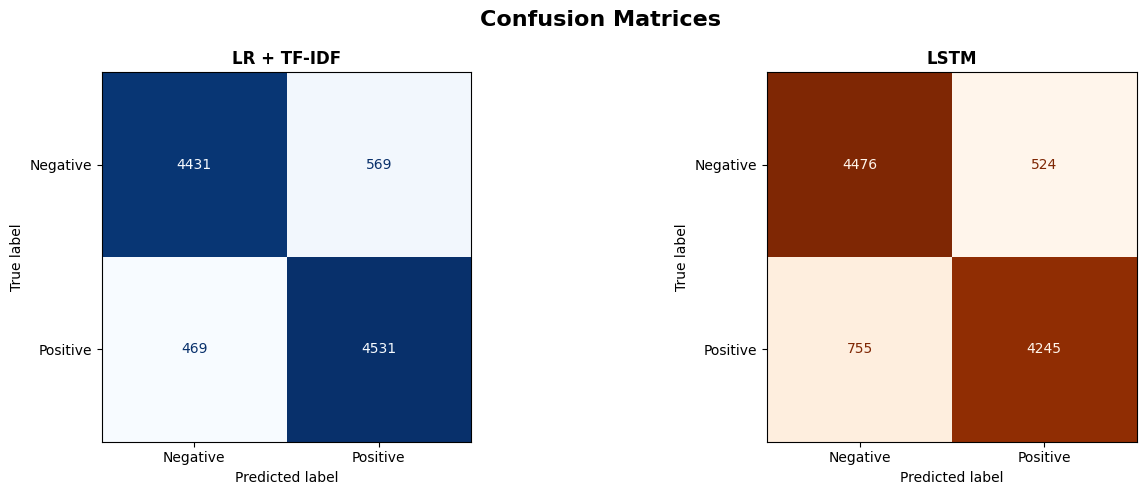

 Confusion matrices saved!


In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

# LR + TF-IDF
cm_lr = confusion_matrix(y_test, y_pred_lr_tfidf)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Negative', 'Positive'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('LR + TF-IDF', fontweight='bold')

# LSTM
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(cm_lstm, display_labels=['Negative', 'Positive'])
disp_lstm.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('LSTM', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrices.png', dpi=150)
plt.show()
print(' Confusion matrices saved!')

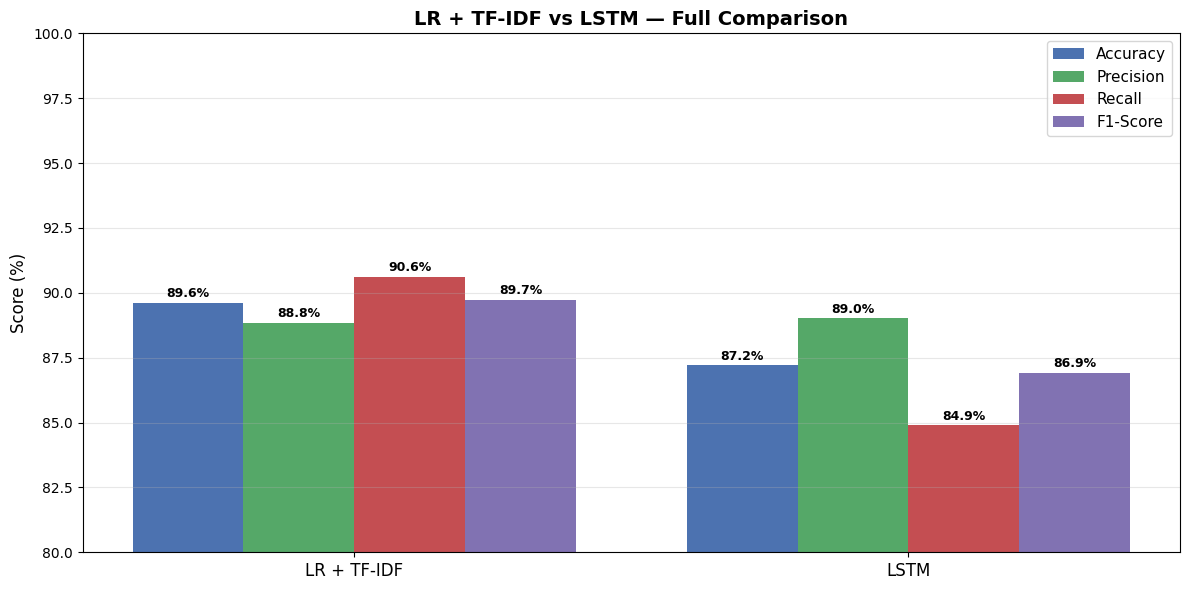

 Comparison chart saved!


In [62]:
import numpy as np
import matplotlib.pyplot as plt

models  = ['LR + TF-IDF', 'LSTM']
metrics = {
    'Accuracy' : [accuracy_score(y_test, y_pred_lr_tfidf)*100,
                  accuracy_score(y_test_lstm, y_pred_lstm)*100],
    'Precision': [precision_score(y_test, y_pred_lr_tfidf)*100,
                  precision_score(y_test_lstm, y_pred_lstm)*100],
    'Recall'   : [recall_score(y_test, y_pred_lr_tfidf)*100,
                  recall_score(y_test_lstm, y_pred_lstm)*100],
    'F1-Score' : [f1_score(y_test, y_pred_lr_tfidf)*100,
                  f1_score(y_test_lstm, y_pred_lstm)*100],
}

x     = np.arange(len(models))
width = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i*width, values, width, label=metric, color=colors[i])

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(80, 100)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('LR + TF-IDF vs LSTM — Full Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (metric, values) in enumerate(metrics.items()):
    for j, v in enumerate(values):
        ax.text(j + i*width, v + 0.1, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'model_comparison.png', dpi=150)
plt.show()
print(' Comparison chart saved!')

In [63]:
import pandas as pd

summary = pd.DataFrame({
    'Model'    : ['LR + TF-IDF', 'LSTM'],
    'Accuracy' : [f'{accuracy_score(y_test, y_pred_lr_tfidf)*100:.2f}%',
                  f'{accuracy_score(y_test_lstm, y_pred_lstm)*100:.2f}%'],
    'Precision': [f'{precision_score(y_test, y_pred_lr_tfidf)*100:.2f}%',
                  f'{precision_score(y_test_lstm, y_pred_lstm)*100:.2f}%'],
    'Recall'   : [f'{recall_score(y_test, y_pred_lr_tfidf)*100:.2f}%',
                  f'{recall_score(y_test_lstm, y_pred_lstm)*100:.2f}%'],
    'F1-Score' : [f'{f1_score(y_test, y_pred_lr_tfidf)*100:.2f}%',
                  f'{f1_score(y_test_lstm, y_pred_lstm)*100:.2f}%'],
})

summary = summary.set_index('Model')
print('Final Results Summary:')
print(summary.to_string())

# Save summary
summary.to_csv(SAVE_PATH + 'final_results.csv')
print('\n Results saved!')

Final Results Summary:
            Accuracy Precision  Recall F1-Score
Model                                          
LR + TF-IDF   89.62%    88.84%  90.62%   89.72%
LSTM          87.21%    89.01%  84.90%   86.91%

 Results saved!


In [32]:
total    = len(y)
positive = y.sum()
negative = (y == 0).sum()

print(' Simple Statistics:')
print(f'Total reviews    : {total:,}')
print(f'Positive reviews : {positive:,} ({positive/total*100:.1f}%)')
print(f'Negative reviews : {negative:,} ({negative/total*100:.1f}%)')

 Simple Statistics:
Total reviews    : 50,000
Positive reviews : 25,000 (50.0%)
Negative reviews : 25,000 (50.0%)


In [33]:
import pandas as pd
import numpy as np

feature_names = tfidf.get_feature_names_out()

# Get LR weights for each word
weights = lr_tfidf.coef_[0]

# Top positive keywords
top_positive_idx = weights.argsort()[-20:][::-1]
top_positive     = [(feature_names[i], round(weights[i], 4)) for i in top_positive_idx]

# Top negative keywords
top_negative_idx = weights.argsort()[:20]
top_negative     = [(feature_names[i], round(weights[i], 4)) for i in top_negative_idx]

print(' Top 20 Positive Keywords:')
for word, weight in top_positive:
    print(f'   {word:<20} weight: {weight}')

print('\n Top 20 Negative Keywords:')
for word, weight in top_negative:
    print(f'   {word:<20} weight: {weight}')

 Top 20 Positive Keywords:
   excellent            weight: 7.0447
   great                weight: 6.5185
   perfect              weight: 5.7967
   amazing              weight: 5.1977
   hilarious            weight: 4.6903
   wonderful            weight: 4.6544
   brilliant            weight: 4.2897
   one best             weight: 4.2694
   loved                weight: 4.2125
   superb               weight: 4.1129
   favorite             weight: 4.0653
   enjoyable            weight: 4.0602
   today                weight: 3.942
   enjoyed              weight: 3.9343
   fantastic            weight: 3.8764
   fun                  weight: 3.7901
   definitely           weight: 3.6617
   best                 weight: 3.5952
   must see             weight: 3.4521
   incredible           weight: 3.4223

 Top 20 Negative Keywords:
   worst                weight: -9.1569
   awful                weight: -7.8791
   bad                  weight: -6.8417
   waste                weight: -6.7473
   bor

# IMPROVED RESPONSE

In [35]:
from scipy.sparse import hstack
import numpy as np

def analyze_review(review_text):
    # Preprocess
    import re
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    stop_words  = set(stopwords.words('english'))
    lemmatizer  = WordNetLemmatizer()

    # Clean
    text = re.sub(r'\[PERSON\]',     ' ', review_text)
    text = re.sub(r'\[MOVIE_NAME\]', ' ', text)
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    tokens = word_tokenize(text)
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
    tokens = [t for t in tokens if t and t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    cleaned = ' '.join(tokens)

    # Vectorize
    X = tfidf.transform([cleaned])

    # Predict
    prediction = lr_tfidf.predict(X)[0]
    sentiment  = 'Positive' if prediction == 1 else 'Negative'

    # Get reason (top words that influenced prediction)
    feature_names = tfidf.get_feature_names_out()
    weights       = lr_tfidf.coef_[0]
    x_array       = X.toarray()[0]

    # Multiply word presence by its weight
    word_scores = {
        feature_names[i]: round(x_array[i] * weights[i], 4)
        for i in range(len(feature_names))
        if x_array[i] > 0
    }

    # Sort by absolute impact
    sorted_words = sorted(word_scores.items(), key=lambda x: abs(x[1]), reverse=True)
    top_reasons  = sorted_words[:5]

    # Print improved output
    print(f' Review   : {review_text}')
    print(f'  Sentiment: {sentiment}')
    print(f' Reason   : {", ".join([w for w, s in top_reasons])}')
    print(f' Keywords : {", ".join([w for w, s in top_reasons[:3]])}')
    print()

# Test on sample reviews
sample_reviews = [
    "The movie was absolutely brilliant and inspiring",
    "This was the worst film I have ever seen, terrible acting",
    "The plot was boring and the characters were dull",
    "An outstanding performance by the entire cast",
    "Complete waste of time, very disappointing"
]

print('=' * 60)
for review in sample_reviews:
    analyze_review(review)
    print('-' * 60)

 Review   : The movie was absolutely brilliant and inspiring
  Sentiment: Positive
 Reason   : brilliant, inspiring, absolutely, movie
 Keywords : brilliant, inspiring, absolutely

------------------------------------------------------------
 Review   : This was the worst film I have ever seen, terrible acting
  Sentiment: Negative
 Reason   : worst, terrible, worst film, seen, ever
 Keywords : worst, terrible, worst film

------------------------------------------------------------
 Review   : The plot was boring and the characters were dull
  Sentiment: Negative
 Reason   : boring, dull, plot, character
 Keywords : boring, dull, plot

------------------------------------------------------------
 Review   : An outstanding performance by the entire cast
  Sentiment: Positive
 Reason   : outstanding, performance, entire, cast
 Keywords : outstanding, performance, entire

------------------------------------------------------------
 Review   : Complete waste of time, very disappointing
 

In [36]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()
weights       = lr_tfidf.coef_[0]

# Separate positive and negative reviews
pos_reviews = df[df['sentiment'] == 'positive']['cleaned_review']
neg_reviews = df[df['sentiment'] == 'negative']['cleaned_review']

# Vectorize separately
X_pos = tfidf.transform(pos_reviews)
X_neg = tfidf.transform(neg_reviews)

# Mean TF-IDF score per word
pos_scores = X_pos.mean(axis=0).A1
neg_scores = X_neg.mean(axis=0).A1

# Top patterns in positive reviews
top_pos_patterns = pd.Series(pos_scores, index=feature_names).nlargest(10)
top_neg_patterns = pd.Series(neg_scores, index=feature_names).nlargest(10)

print(' Common Patterns in POSITIVE reviews:')
print('   Most positive feedback is related to:')
for word, score in top_pos_patterns.items():
    print(f'   → {word:<20} (score: {score:.4f})')

print('\n Common Patterns in NEGATIVE reviews:')
print('   Most complaints are related to:')
for word, score in top_neg_patterns.items():
    print(f'   → {word:<20} (score: {score:.4f})')

 Common Patterns in POSITIVE reviews:
   Most positive feedback is related to:
   → film                 (score: 0.0396)
   → movie                (score: 0.0394)
   → one                  (score: 0.0297)
   → nt                   (score: 0.0274)
   → great                (score: 0.0255)
   → like                 (score: 0.0230)
   → good                 (score: 0.0230)
   → time                 (score: 0.0225)
   → story                (score: 0.0224)
   → see                  (score: 0.0215)

 Common Patterns in NEGATIVE reviews:
   Most complaints are related to:
   → movie                (score: 0.0471)
   → nt                   (score: 0.0379)
   → film                 (score: 0.0368)
   → one                  (score: 0.0289)
   → like                 (score: 0.0280)
   → bad                  (score: 0.0273)
   → even                 (score: 0.0239)
   → would                (score: 0.0233)
   → good                 (score: 0.0224)
   → time                 (score: 0.0217)


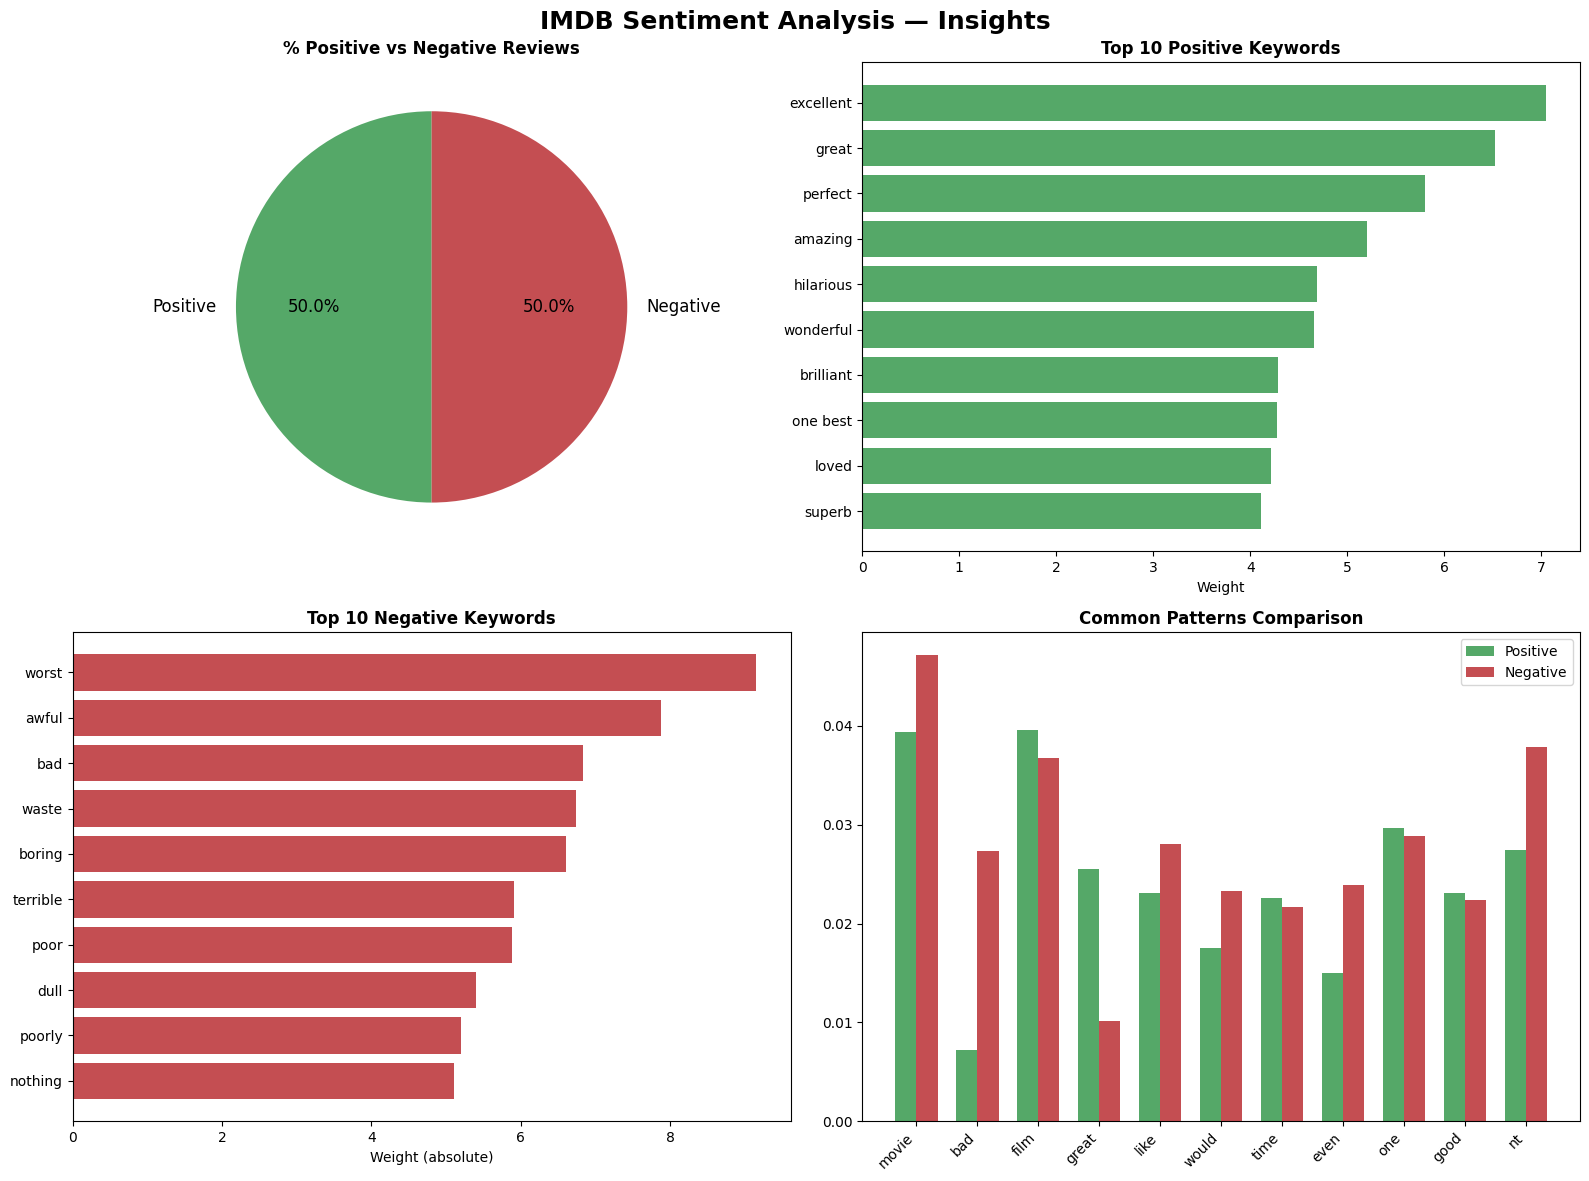

 Insights visualization saved!


In [38]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('IMDB Sentiment Analysis — Insights', fontsize=18, fontweight='bold')

# 1. Pie chart — positive vs negative
axes[0, 0].pie(
    [positive, negative],
    labels=['Positive', 'Negative'],
    colors=['#55A868', '#C44E52'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0, 0].set_title('% Positive vs Negative Reviews', fontweight='bold')

# 2. Top positive keywords
pos_words   = [w for w, s in top_positive[:10]]
pos_weights = [s for w, s in top_positive[:10]]
axes[0, 1].barh(pos_words[::-1], pos_weights[::-1], color='#55A868')
axes[0, 1].set_title('Top 10 Positive Keywords', fontweight='bold')
axes[0, 1].set_xlabel('Weight')

# 3. Top negative keywords
neg_words   = [w for w, s in top_negative[:10]]
neg_weights = [abs(s) for w, s in top_negative[:10]]
axes[1, 0].barh(neg_words[::-1], neg_weights[::-1], color='#C44E52')
axes[1, 0].set_title('Top 10 Negative Keywords', fontweight='bold')
axes[1, 0].set_xlabel('Weight (absolute)')

# 4. Common patterns comparison
pattern_words = list(set(top_pos_patterns.index[:8].tolist() +
                         top_neg_patterns.index[:8].tolist()))
pos_vals = [pos_scores[list(feature_names).index(w)]
            if w in feature_names else 0 for w in pattern_words]
neg_vals = [neg_scores[list(feature_names).index(w)]
            if w in feature_names else 0 for w in pattern_words]

x     = np.arange(len(pattern_words))
width = 0.35
axes[1, 1].bar(x - width/2, pos_vals, width, label='Positive', color='#55A868')
axes[1, 1].bar(x + width/2, neg_vals, width, label='Negative', color='#C44E52')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(pattern_words, rotation=45, ha='right')
axes[1, 1].set_title('Common Patterns Comparison', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'insights.png', dpi=150)
plt.show()
print(' Insights visualization saved!')